In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from collections import Counter
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
from torch.utils.data import Dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.neighbors import KNeighborsClassifier
import torch.nn as nn
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from sklearn.naive_bayes import GaussianNB,  MultinomialNB
from sklearn.ensemble import GradientBoostingClassifier

In [2]:
dataset = load_dataset('Tobi-Bueck/customer-support-tickets', split = 'train')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

aa_dataset-tickets-multi-lang-5-2-50-ver(…):   0%|          | 0.00/26.0M [00:00<?, ?B/s]

(…)set-tickets-german_normalized_50_5_2.csv: 0.00B [00:00, ?B/s]

dataset-tickets-multi-lang-4-20k.csv:   0%|          | 0.00/18.8M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/61765 [00:00<?, ? examples/s]

In [3]:
train_idx = pd.read_csv('/content/train_idx.txt')
val_idx = pd.read_csv('/content/val_idx.txt')
test_idx = pd.read_csv('/content/test_idx.txt')
train_data = dataset.select(train_idx.values)
test_data = dataset.select(test_idx.values)
val_data = dataset.select(val_idx.values)


# EDA    

#### Top queues

Counter({'Technical Support': 11353,
         'Returns and Exchanges': 1956,
         'Billing and Payments': 3853,
         'Sales and Pre-Sales': 1228,
         'Service Outages and Maintenance': 1534,
         'Product Support': 7139,
         'Customer Service': 5905,
         'Human Resources': 730,
         'IT Support': 4673,
         'General Inquiry': 532,
         'Food & Drink/Groceries': 260,
         'Home & Garden/Landscaping': 217,
         'IT & Technology/Hardware Support': 219,
         'News': 313,
         'Shopping/Retail Stores': 226,
         'Online Communities/Forums': 269,
         'Travel & Transportation/Land Travel': 270,
         'Home & Garden/Home Improvement': 285,
         'Jobs & Education/Recruitment': 235,
         'Business & Industrial/Manufacturing': 270,
         'Hobbies & Leisure/Collectibles': 263,
         'Law & Government/Legal Advice': 241,
         'Books & Literature/Non-Fiction': 252,
         'Beauty & Fitness/Fitness Training': 240,


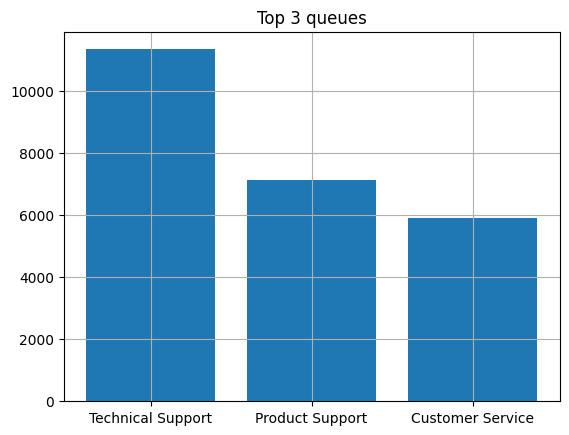

In [20]:
queues = train_data['queue']
queue_counts = Counter(queues)
keys = [i[0] for i in queue_counts.most_common()[:3]]
values = [i[1] for i in queue_counts.most_common()[:3]]
plt.bar(keys, values)
plt.grid(True)
plt.title('Top 3 queues')
queue_counts

In [15]:
train_data

Dataset({
    features: ['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language', 'version', 'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
    num_rows: 49411
})

##### language

In [49]:
train_df = train_data.to_pandas()
val_df = val_data.to_pandas()
test_df = test_data.to_pandas()

Counter({'en': 22613, 'de': 26798})

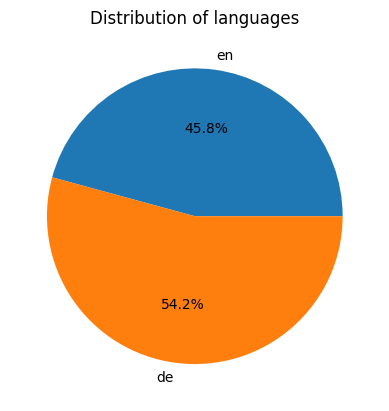

In [50]:
lang = train_df['language']
lang_counts = Counter(lang)
plt.pie(lang_counts.values(), labels=lang_counts.keys(), autopct='%1.1f%%')
plt.grid(True)
plt.title('Distribution of languages')
lang_counts

##### texts

In [51]:
bodies = train_df['body']
text_lengths = [len(str(text)) for text in bodies]
print("Статистика длин текстов:")
print(f"Средняя длина: {np.mean(text_lengths):.2f}")
print(f"Медианная длина: {np.median(text_lengths):.2f}")
print(f"Мин длина: {min(text_lengths)}")
print(f"Макс длина: {max(text_lengths)}")
print(f"Стандартное отклонение: {np.std(text_lengths):.2f}")
percentiles = [25, 50, 75, 90, 95, 99]
for p in percentiles:
    print(f"{p}й перцентиль: {np.percentile(text_lengths, p):.2f}")

Статистика длин текстов:
Средняя длина: 419.40
Медианная длина: 415.00
Мин длина: 4
Макс длина: 2259
Стандартное отклонение: 223.60
25й перцентиль: 233.00
50й перцентиль: 415.00
75й перцентиль: 587.00
90й перцентиль: 702.00
95й перцентиль: 759.00
99й перцентиль: 945.90


# Models

In [56]:
def calculate_metric(y_true_queue, y_pred_queue, y_true_priority, y_pred_priority, y_true_type, y_pred_type):

    macro_f1_queue = f1_score(y_true_queue, y_pred_queue, average='macro')
    acc_priority = accuracy_score(y_true_priority, y_pred_priority)
    acc_type = accuracy_score(y_true_type, y_pred_type)

    core = 0.70 * macro_f1_queue + 0.15 * acc_priority + 0.15 * acc_type

    return {
        'core': core,
        'macro_f1_queue': macro_f1_queue,
        'acc_priority': acc_priority,
        'acc_type': acc_type
    }

### Baseline model

In [93]:
def baseline_tfidf(splits, classificator, name):
    # Build text
    def make_text(d: pd.DataFrame) -> pd.Series:
        return (d["subject"].fillna("") + "\n\n" + d["body"].fillna("")).astype(str)

    X_train = make_text(splits["train"])
    X_test = make_text(splits["test"])

    vec = TfidfVectorizer(
        max_features=200_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    Xtr = vec.fit_transform(X_train)
    Xte = vec.transform(X_test)

    results = {}

    print(f"\n=== BASELINE: TF-IDF + c {name}===")
    for target in ["queue", "priority", "type"]:
        ytr = splits["train"][target].astype(str).values
        yte = splits["test"][target].astype(str).values

        clf = classificator
        clf.fit(Xtr, ytr)
        pred = clf.predict(Xte)

        acc = float(accuracy_score(yte, pred))
        if target == "queue":
            mf1 = float(f1_score(yte, pred, average="macro"))
            results["queue_acc"] = acc
            results["queue_macro_f1"] = mf1
            print(f"{target}: acc={acc:.4f}  macro_f1={mf1:.4f}")
        else:
            results[f"{target}_acc"] = acc
            print(f"{target}: acc={acc:.4f}")

    # final score (по вашей формуле)
    score = 0.70 * results["queue_macro_f1"] + 0.15 * results["priority_acc"] + 0.15 * results["type_acc"]
    print("\n=== FINAL SCORE (baseline) ===")
    print(f"Score = {score:.4f}  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))")


In [95]:
splits = {'train' : train_df, 'test' : val_df}
clasificators = {'LinaerSVC': LinearSVC(),  'MultinomialNB': MultinomialNB(), 'LogisticRegression' : LogisticRegression(max_iter=1000) }
for name, model in clasificators.items():
  baseline_tfidf(splits, model, name)


=== BASELINE: TF-IDF + c LinaerSVC===
queue: acc=0.6892  macro_f1=0.8988
priority: acc=0.7200
type: acc=0.8933

=== FINAL SCORE (baseline) ===
Score = 0.8711  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))

=== BASELINE: TF-IDF + c MultinomialNB===
queue: acc=0.2845  macro_f1=0.0342
priority: acc=0.5587
type: acc=0.7645

=== FINAL SCORE (baseline) ===
Score = 0.2224  (0.70*MacroF1(queue) + 0.15*Acc(priority) + 0.15*Acc(type))

=== BASELINE: TF-IDF + c LogisticRegression===


KeyboardInterrupt: 

### MultiTaskTransformer

In [16]:
class MultitaskTransformer(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        # Один общий BERT
        self.bert = AutoModel.from_pretrained('bert-base-uncased')
        self.hidden_size = self.bert.config.hidden_size
        self.dropout = nn.Dropout(dropout)


        # Разные головы для разных задач
        self.queue_head = nn.Linear(self.hidden_size, 52)      # 52 класса
        self.priority_head = nn.Linear(self.hidden_size, 5)    # 5 классов
        self.type_head = nn.Linear(self.hidden_size, 5)        # 5 классов
        self._init_weights()
    def _init_weights(self):
        """Инициализация весов для голов классификации"""
        for module in [self.queue_head, self.priority_head, self.type_head]:
            nn.init.xavier_uniform_(module.weight)
            nn.init.zeros_(module.bias)

    def forward(self, input_ids, attention_mask):
        # Общий encoder
        outputs = self.bert(input_ids, attention_mask)
        pooled = outputs.last_hidden_state[:, 0, :]  # [CLS]
        pooled = self.dropout(pooled)

        # Каждая задача делает свое предсказание
        queue_logits = self.queue_head(pooled)        # [batch, 52]
        priority_logits = self.priority_head(pooled)  # [batch, 5]
        type_logits = self.type_head(pooled)          # [batch, 5]

        return (queue_logits, priority_logits, type_logits)
    def get_loss(self, queue_logits, priority_logits, type_logits,
                 queue_labels, priority_labels, type_labels,
                 task_weights=[1.0, 0.5, 0.5]):
        """
        Считаем взвешенный loss для всех задач
        """
        loss_fn = nn.CrossEntropyLoss()

        loss_queue = loss_fn(queue_logits, queue_labels)
        loss_priority = loss_fn(priority_logits, priority_labels)
        loss_type = loss_fn(type_logits, type_labels)

        # Взвешенная сумма
        total_loss = (task_weights[0] * loss_queue +
                     task_weights[1] * loss_priority +
                     task_weights[2] * loss_type)

        return {
            'total_loss': total_loss,
            'loss_queue': loss_queue.item(),
            'loss_priority': loss_priority.item(),
            'loss_type': loss_type.item()
        }


In [14]:
class MultitaskDataset(Dataset):
    def __init__(self, data, tokenizer, max_length=256, queue2id=None, priority2id=None, type2id=None):
        self.data = data
        self.tokenizer = tokenizer
        self.max_length = max_length

        # Создаем маппинги если не переданы
        if queue2id is None:
            self.queues = sorted(list(set(data['queue'])))
            self.queue2id = {q: i for i, q in enumerate(self.queues)}
        else:
            self.queue2id = queue2id

        if priority2id is None:
            self.priorities = sorted(list(set(data['priority'])))
            self.priority2id = {p: i for i, p in enumerate(self.priorities)}
        else:
            self.priority2id = priority2id

        if type2id is None:
            types_clean = ['Unknown' if t is None else t for t in data['type']]
            self.types = sorted(list(set(types_clean)))
            self.type2id = {t: i for i, t in enumerate(self.types)}
        else:
            self.type2id = type2id

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        type_val = item['type']
        if type_val is None:
            type_val = 'Unknown'

        # Объединяем subject и body
        text = f"{item['subject']} {item['body']}"

        # Токенизация
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'queue_labels': torch.tensor(self.queue2id[item['queue']]),
            'priority_labels': torch.tensor(self.priority2id[item['priority']]),
            'type_labels': torch.tensor(self.type2id[type_val])
        }


In [20]:
def train_multitask_model(model, train_loader, val_loader, epochs=5, lr=2e-5, device='cuda'):
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps
    )

    model.to(device)
    best_val_score = 0

    for epoch in range(epochs):
        # Training
        model.train()
        train_losses = []

        for batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs} [Train]'):
            # Move to device
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            queue_labels = batch['queue_labels'].to(device)
            priority_labels = batch['priority_labels'].to(device)
            type_labels = batch['type_labels'].to(device)

            # Forward pass
            queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)

            # Calculate loss
            losses = model.get_loss(
                queue_logits,
                priority_logits,
                type_logits,
                queue_labels,
                priority_labels,
                type_labels
            )


            # Backward pass
            optimizer.zero_grad()
            losses['total_loss'].backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()

            train_losses.append(losses['total_loss'].item())

        # Validation
        val_metrics = evaluate_multitask_model(model, val_loader, device)

        print(f"\nEpoch {epoch+1}:")
        print(f"  Train Loss: {np.mean(train_losses):.4f}")
        print(f"  Val Queue F1: {val_metrics['queue_macro_f1']:.4f}")
        print(f"  Val Priority Acc: {val_metrics['priority_acc']:.4f}")
        print(f"  Val Type Acc: {val_metrics['type_acc']:.4f}")

        # Сохраняем лучшую модель
        current_score = (0.7 * val_metrics['queue_macro_f1'] +
                        0.15 * val_metrics['priority_acc'] +
                        0.15 * val_metrics['type_acc'])

        if current_score > best_val_score:
            best_val_score = current_score
            torch.save(model.state_dict(), 'best_multitask_model.pt')
            print(f"  ✅ New best model! Score: {current_score:.4f}")


# Функция для evaluation
@torch.no_grad()
def evaluate_multitask_model(model, data_loader, device='cuda'):
    model.eval()

    all_queue_preds = []
    all_queue_labels = []
    all_priority_preds = []
    all_priority_labels = []
    all_type_preds = []
    all_type_labels = []

    for batch in tqdm(data_loader, desc='Evaluating'):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        queue_logits, priority_logits, type_logits = model(input_ids, attention_mask)

        # Получаем предсказания
        queue_preds = torch.argmax(queue_logits, dim=-1)
        priority_preds = torch.argmax(priority_logits, dim=-1)
        type_preds = torch.argmax(type_logits, dim=-1)

        # Собираем
        all_queue_preds.extend(queue_preds.cpu().numpy())
        all_queue_labels.extend(batch['queue_labels'].numpy())
        all_priority_preds.extend(priority_preds.cpu().numpy())
        all_priority_labels.extend(batch['priority_labels'].numpy())
        all_type_preds.extend(type_preds.cpu().numpy())
        all_type_labels.extend(batch['type_labels'].numpy())

    # Считаем метрики
    metrics = {
        'queue_macro_f1': f1_score(all_queue_labels, all_queue_preds, average='macro'),
        'queue_micro_f1': f1_score(all_queue_labels, all_queue_preds, average='micro'),
        'queue_acc': accuracy_score(all_queue_labels, all_queue_preds),
        'priority_acc': accuracy_score(all_priority_labels, all_priority_preds),
        'type_acc': accuracy_score(all_type_labels, all_type_preds),
    }

    return metrics

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
model = MultitaskTransformer()
train_dataset = MultitaskDataset(train_data, tokenizer)
val_dataset = MultitaskDataset(val_data, tokenizer,
                               queue2id=train_dataset.queue2id,
                               priority2id=train_dataset.priority2id,
                               type2id=train_dataset.type2id)

test_dataset = MultitaskDataset(val_data, tokenizer,
                               queue2id=train_dataset.queue2id,
                               priority2id=train_dataset.priority2id,
                               type2id=train_dataset.type2id)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=32)

In [25]:
# 3. Тренировка
train_multitask_model(model, train_loader, val_loader, epochs=5)

# 4. Оценка
test_metrics = evaluate_multitask_model(model, test_loader)
print(f"Test Macro-F1 (queue): {test_metrics['queue_macro_f1']:.4f}")

# 5. Core metric
core = (0.7 * test_metrics['queue_macro_f1'] +
        0.15 * test_metrics['priority_acc'] +
        0.15 * test_metrics['type_acc'])
print(f"Core metric: {core:.4f}")



Evaluating: 100%|██████████| 193/193 [01:30<00:00,  2.14it/s]



Epoch 1:
  Train Loss: 1.9688
  Val Queue F1: 0.8030
  Val Priority Acc: 0.5823
  Val Type Acc: 0.8518
  ✅ New best model! Score: 0.7772


Epoch 2/5 [Train]:  20%|██        | 618/3089 [07:05<28:20,  1.45it/s]


KeyboardInterrupt: 

In [26]:
test_metrics = evaluate_multitask_model(model, test_loader)

Evaluating: 100%|██████████| 193/193 [01:30<00:00,  2.14it/s]


In [27]:
!git clone https://github.com/ikanam-ai/NLP-2026.git

Cloning into 'NLP-2026'...
remote: Enumerating objects: 61, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (2/2), done.
remote: Total 61 (delta 6), reused 6 (delta 6), pack-reused 53 (from 1)
Receiving objects: 100% (61/61), 1.32 MiB | 25.50 MiB/s, done.
Resolving deltas: 100% (15/15), done.


In [29]:
cd /content/NLP-2026/homework

/content/NLP-2026/homework


In [31]:
%cd /content/NLP-2026

/content/NLP-2026


In [32]:
!git checkout -b решение-дз1

Switched to a new branch 'решение-дз1'
